# Task 1

### Basic search engine
This section goes through the workflow of my search engine:
1. data preprocessing
2. creating the embedding model
3. initiating the vector database and loading vectors
4. testing if everything works

#### 1.1 Data preprocessing/collection
Here documents are loaded and split into chunks to later be encoded.

In [1]:
# get text from sample pdfs
from src.basic_code_search.document_loader import load_pdf_documents

text = load_pdf_documents(folder_path="data")
print(f"Loaded {len(text)} characters from PDF files.")


Loaded 128733 characters from PDF files.


In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_text(text)

print(f"Split into {len(chunks)} chunks.")

Split into 290 chunks.


#### 1.2 Creating embedding model
Here I'm using one of the most popular open-sourced embedding models: all-MiniLM-L6-v2

In [3]:
from src.basic_code_search.embedding_model import EmbeddingModel

embedding_model = EmbeddingModel(model_name='sentence-transformers/all-MiniLM-L6-v2')
embeddings = embedding_model.encode(chunks)

print(f"Generated {len(embeddings)} embeddings.")

c:\Users\kacpe\Documents\GitHub\Basic-Code-Search\.venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
c:\Users\kacpe\Documents\GitHub\Basic-Code-Search\.venv\Lib\site-packages\sentence_transformers\evaluation\SentenceEvaluator.py:81: SyntaxWarning: invalid escape sequence '\g'
  return re.sub(r"([a-z])([A-Z])", "\g<1> \g<2>", class_name)
c:\Users\kacpe\Documents\GitHub\Basic-Code-Search\.venv\Lib\site-packages\sentence_transformers\model_card.py:524: SyntaxWarning: invalid escape sequence '\d'
  if dataset_name and re.match("_datase

Generated 290 embeddings.


#### 1.3 and 1.4 Initialazing and testing the dataset

In [4]:
from src.basic_code_search.search_engine import SearchEngine

search_engine = SearchEngine(embedding_model=embedding_model, collection_name="basic_search_db", top_k=3)

# open connection
search_engine.open()

# load text data
search_engine.load_text_data(chunks, batch_size=128)

# example search
query = "What is a transformer model?"
results = search_engine.search(query)
for result in results:
    print(f"\nResult {result.id} (Score: {result.score}):\n{result.payload['text']}")

# close connection
search_engine.close()


Result 7bf87ab9-80b1-47c3-ab95-f588bbfdad7b (Score: 0.5118746):
language modeling tasks [34].
To the best of our knowledge, however, the Transformer is the first transduction model relying
entirely on self-attention to compute representations of its input and output without using sequence-
aligned RNNs or convolution. In the following sections, we will describe the Transformer, motivate
self-attention and discuss its advantages over models such as [17, 18] and [9].
3 Model Architecture

Result 0d2c13b6-b009-4df0-aed2-45d6384996ef (Score: 0.47969747):
block, computing hidden representations in parallel for all input and output positions. In these models,
the number of operations required to relate signals from two arbitrary input or output positions grows
in the distance between positions, linearly for ConvS2S and logarithmically for ByteNet. This makes
it more difficult to learn dependencies between distant positions [ 12]. In the Transformer this is

Result 08203805-cb7b-429b-a839-20

# Task 2

### Metrics
This section evaluates the off shelf model on CosQA dataset using Recall@10, MRR@10 and NDCG@10 as metrics

#### 2.1 Exploring the dataset

In [5]:
from datasets import load_dataset

corpus = load_dataset("CoIR-Retrieval/cosqa", "corpus")['corpus']
queries = load_dataset("CoIR-Retrieval/cosqa", "queries")['queries']
default = load_dataset("CoIR-Retrieval/cosqa", "default")

Using the latest cached version of the dataset since CoIR-Retrieval/cosqa couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'corpus' at C:\Users\kacpe\.cache\huggingface\datasets\CoIR-Retrieval___cosqa\corpus\0.0.0\0846fa3b963a21bead36e9fab61451fc83b777a6 (last modified on Thu Oct 30 15:27:40 2025).


In [6]:
print(default)
print(default['train'][0])

DatasetDict({
    train: Dataset({
        features: ['query-id', 'corpus-id', 'score'],
        num_rows: 19604
    })
    test: Dataset({
        features: ['query-id', 'corpus-id', 'score'],
        num_rows: 500
    })
    valid: Dataset({
        features: ['query-id', 'corpus-id', 'score'],
        num_rows: 500
    })
})
{'query-id': 'q1', 'corpus-id': 'd1', 'score': 0}


In [7]:
print(queries)
print(queries[0])

Dataset({
    features: ['_id', 'partition', 'text', 'title', 'language', 'meta_information'],
    num_rows: 20604
})
{'_id': 'q1', 'partition': 'train', 'text': 'python code to write bool value 1', 'title': '', 'language': '', 'meta_information': {'dummy_field': ''}}


In [8]:
print(corpus)
print(corpus[0])

Dataset({
    features: ['_id', 'partition', 'text', 'title', 'language', 'meta_information'],
    num_rows: 20604
})
{'_id': 'd1', 'partition': 'train', 'text': 'def writeBoolean(self, n):\n        """\n        Writes a Boolean to the stream.\n        """\n        t = TYPE_BOOL_TRUE\n\n        if n is False:\n            t = TYPE_BOOL_FALSE\n\n        self.stream.write(t)', 'title': '', 'language': 'PYTHON', 'meta_information': {'dummy_field': ''}}


#### 2.2 Preporocessing prior to evaluation

In [9]:
pd_queries = queries.to_pandas()
pd_corpus = corpus.to_pandas()
pd_test = default['test'].to_pandas()

test_full_texts = pd_test.merge(pd_queries, left_on='query-id', right_on='_id', how='left')[['query-id', 'corpus-id', 'text', 'score']].rename(columns={'text': 'query_text'})
test_full_texts = test_full_texts.merge(pd_corpus, left_on='corpus-id', right_on='_id', how='left')[['query-id', 'corpus-id', 'query_text', 'text', 'score']].rename(columns={'text': 'corpus_text'})

print(test_full_texts.head())

  query-id corpus-id                             query_text  \
0   q20105    d20105       sort by a token in string python   
1   q20106    d20106          python check file is readonly   
2   q20107    d20107  declaring empty numpy array in python   
3   q20108    d20108  test for iterable is string in python   
4   q20109    d20109     python print results of query loop   

                                         corpus_text  score  
0  def _process_and_sort(s, force_ascii, full_pro...      1  
1  def is_readable(filename):\n    """Check if fi...      1  
2  def empty(self, name, **kwargs):\n        """C...      1  
3  def is_iterable_but_not_string(obj):\n    """\...      1  
4  def print_runs(query):\n    """ Print all rows...      1  


#### 2.3 Evaluating the off-shelf model

In [ ]:
import traceback

embedding_model = EmbeddingModel(model_name='sentence-transformers/all-MiniLM-L6-v2')

# start search engine
search_engine = SearchEngine(embedding_model=embedding_model, collection_name="basic_search_db", top_k=10)
try:
    # open connection to vector database
    search_engine.open()

    # load corpus into search engine
    search_engine.load_text_data(ids=list(corpus['_id']), texts=list(corpus['text']), batch_size=2048, verbose=True)

    model_responses = []
    for test_query in test_full_texts['query_text']:
        results = search_engine.search(test_query)
        model_responses.append([res.payload['dataset_id'] for res in results])

    print() # empty line for better readability
    search_engine.evaluate(predictions=model_responses, targets=list(test_full_texts['corpus-id']))

    search_engine.close()
except Exception as e:
    search_engine.close()
    print(traceback.print_exc())

TypeError: EmbeddingModel.__init__() missing 1 required positional argument: 'model_name'

# Task 3

### Fine-tuning

In this section I will fine-tune the all-MiniLM-L6-v2 on CosQA dataset and compare the performance before and after training.

#### 3.1 Preprocessing
SentenceTransformerTrainer requires data to be arranged in specific way for each of the loss functions, this is wh additional preporcessing is required. The loss function of choice in this example is Multiple Negatives Ranking loss which is praised for it's flexibility and is more lenient towards negatives then Triplet loss.

In [ ]:
from datasets import Dataset

# prepare train and eval datasets
datasets = {
    'train': default['train'],
    'valid': default['valid'],
}

for name, dataset in datasets.items():
    current_ds = dataset.to_pandas()
    current_ds = current_ds[['query-id', 'corpus-id', 'score']]

    # create new column with negative relation
    last_corpus_id = current_ds['corpus-id'].iloc[-1]
    current_ds['negative_corpus-id'] = current_ds['corpus-id'].shift(1, fill_value=last_corpus_id)

    # leave only positive samples
    current_ds = current_ds[current_ds['score'] == 1]
    current_ds = current_ds[['query-id', 'corpus-id', 'negative_corpus-id']]

    # get full texts from queries and corpus
    current_ds = current_ds.merge(pd_queries, left_on='query-id', right_on='_id', how='left')[['query-id', 'corpus-id', 'negative_corpus-id', 'text']].rename(columns={'text': 'anchor'})
    current_ds = current_ds.merge(pd_corpus, left_on='corpus-id', right_on='_id', how='left')[['anchor', 'text', 'negative_corpus-id']].rename(columns={'text': 'positive'})
    current_ds = current_ds.merge(pd_corpus, left_on='negative_corpus-id', right_on='_id', how='left')[['anchor', 'positive', 'text']].rename(columns={'text': 'negative'})

    # shuffle dataset
    current_ds = current_ds.sample(frac=1, random_state=42).reset_index(drop=True)
    # save as HuggingFace Dataset
    current_ds = current_ds.to_dict(orient='list')
    current_ds = Dataset.from_dict(current_ds)

    # update datasets dictionary
    datasets[name] = current_ds
    
    print(name, current_ds)

train Dataset({
    features: ['anchor', 'positive', 'negative'],
    num_rows: 9020
})
valid Dataset({
    features: ['anchor', 'positive', 'negative'],
    num_rows: 500
})


#### 3.2 Setting up training

In [ ]:
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers import SentenceTransformerTrainingArguments

fine_tuned_model = EmbeddingModel(model_name='sentence-transformers/all-MiniLM-L6-v2')

args = SentenceTransformerTrainingArguments(
    # Required parameter:
    output_dir="results/fine-tuned/cosqa-mnr-loss",
    # Optional training parameters:
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    # Optional tracking/debugging parameters:
    eval_strategy="steps",
    eval_steps=10,
    save_strategy="steps",
    save_total_limit=1,
    logging_steps=10,
)

history = fine_tuned_model.train(
    train_dataset=datasets['train'],
    eval_dataset=datasets['valid'],
    loss_function=MultipleNegativesRankingLoss,
    args=args
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss
10,0.087400,0.093519
20,0.189900,0.088896
30,0.116000,0.082869
40,0.119300,0.076451
50,0.126600,0.070141
60,0.109700,0.066730
70,0.071200,0.064969
80,0.147700,0.062677
90,0.118500,0.060877
100,0.059300,0.059041


KeyboardInterrupt: 

#### 3.3 Evaluation
Here one can see that the model is learning, even though the training loss in not smooth, the validation loss clearly starts to converege. The calculated metrics show that model did indeed improved, increasing it's Recall@10 from 0.4760 to 0.5300, MRR@10 from 0.2436 to 0.2479 and NDCG@10 from 0.2992 to 0.3152.

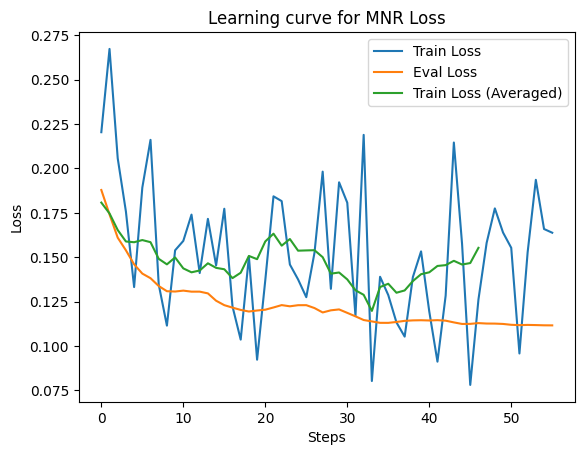

In [ ]:
train_loss_history = history['train_loss_history']
eval_loss_history = history['eval_loss_history']

import numpy as np

window_size = 10
train_his_averaged = np.convolve(train_loss_history, np.ones(window_size)/window_size, mode='valid')

import matplotlib.pyplot as plt

plt.title('Learning curve for MNR Loss')
plt.plot(train_loss_history, label='Train Loss')
plt.plot(eval_loss_history, label='Eval Loss')
plt.plot(train_his_averaged, label='Train Loss (Averaged)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
search_engine = SearchEngine(embedding_model=fine_tuned_model, collection_name="basic_search_db", top_k=10)

try:
    # open connection to vector database
    search_engine.open()

    # load corpus into search engine
    search_engine.load_text_data(ids=list(corpus['_id']), texts=list(corpus['text']), batch_size=2048, verbose=True)

    model_responses = []
    for test_query in test_full_texts['query_text']:
        results = search_engine.search(test_query)
        model_responses.append([res.payload['dataset_id'] for res in results])

    print() # empty line for better readability
    search_engine.evaluate(predictions=model_responses, targets=list(test_full_texts['corpus-id']))

    search_engine.close()
except Exception as e:
    search_engine.close()
    print(traceback.print_exc())

Encoding 20604 texts into embeddings...
Encoding done.

Upserting 20604 vectors into the database in batches of 2048...
Upserted batch 1 with 2048 vectors.
Upserted batch 2 with 2048 vectors.
Upserted batch 3 with 2048 vectors.
Upserted batch 4 with 2048 vectors.
Upserted batch 5 with 2048 vectors.
Upserted batch 6 with 2048 vectors.
Upserted batch 7 with 2048 vectors.
Upserted batch 8 with 2048 vectors.
Upserted batch 9 with 2048 vectors.
Upserted batch 10 with 2048 vectors.
Upserted batch 11 with 124 vectors.

Evaluation Metrics:
Recall@10: 0.5300
MRR@10: 0.2479
NDCG@10: 0.3152


#### Original loss function experiment
Originally I thought the Contrastive loss was a good idea, as the CosQA default dataset seemed to be set up perfectly for it. However when I run the experiment the model was getting worse then the original. I believe the issue is either overfitting or I messed something up when loading the data :). The results of this run can be seen below, it follws the same workflow as MNR loss example.

In [ ]:
# prepare train and eval datasets
datasets = {
    'train': default['train'],
    'valid': default['valid'],
}

for name, dataset in datasets.items():
    current_ds = dataset.to_pandas()

    # get full texts from queries and corpus
    current_ds = current_ds.merge(pd_queries, left_on='query-id', right_on='_id', how='left')[['query-id', 'corpus-id', 'text', 'score']].rename(columns={'text': 'anchor'})
    current_ds = current_ds.merge(pd_corpus, left_on='corpus-id', right_on='_id', how='left')[['anchor', 'text', 'score']].rename(columns={'text': 'positive/negative', 'score': 'label'})

    # shuffle dataset
    current_ds = current_ds.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # save as HuggingFace Dataset
    current_ds = current_ds.to_dict(orient='list')
    current_ds = Dataset.from_dict(current_ds)

    # update datasets dictionary
    datasets[name] = current_ds
    
    print(name, current_ds)

train Dataset({
    features: ['anchor', 'positive/negative', 'label'],
    num_rows: 19604
})
valid Dataset({
    features: ['anchor', 'positive/negative', 'label'],
    num_rows: 500
})


In [ ]:
from sentence_transformers.losses import ContrastiveLoss

fine_tuned_model = EmbeddingModel(model_name='sentence-transformers/all-MiniLM-L6-v2')

args = SentenceTransformerTrainingArguments(
    # Required parameter:
    output_dir="results/fine-tuned/cosqa-contrastive-loss",
    # Optional training parameters:
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    # Optional tracking/debugging parameters:
    eval_strategy="steps",
    eval_steps=10,
    save_strategy="steps",
    save_total_limit=1,
    logging_steps=10,
)

history = fine_tuned_model.train(
    train_dataset=datasets['train'],
    eval_dataset=datasets['valid'],
    loss_function=ContrastiveLoss,
    args=args
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss
10,0.043100,0.066110
20,0.038200,0.060212
30,0.042800,0.050403
40,0.037100,0.038691
50,0.032600,0.031873
60,0.034500,0.027607
70,0.032100,0.023834
80,0.032400,0.025928
90,0.033100,0.035737
100,0.032900,0.037284


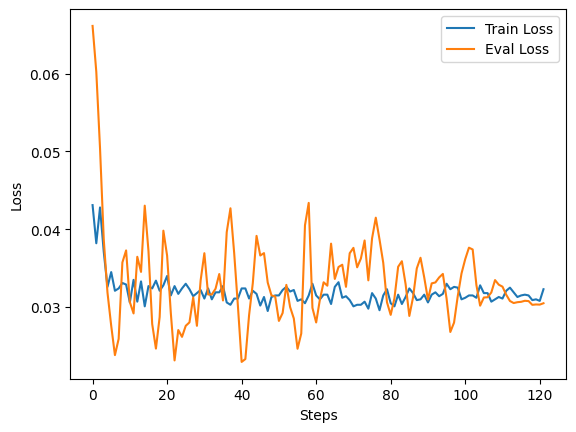

In [ ]:
train_loss_history = history['train_loss_history']
eval_loss_history = history['eval_loss_history']

plt.plot(train_loss_history, label='Train Loss')
plt.plot(eval_loss_history, label='Eval Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
search_engine = SearchEngine(embedding_model=fine_tuned_model, collection_name="basic_search_db", top_k=10)

try:
    # open connection to vector database
    search_engine.open()

    # load corpus into search engine
    search_engine.load_text_data(ids=list(corpus['_id']), texts=list(corpus['text']), batch_size=2048, verbose=True)

    model_responses = []
    for test_query in test_full_texts['query_text']:
        results = search_engine.search(test_query)
        model_responses.append([res.payload['dataset_id'] for res in results])

    print() # empty line for better readability
    search_engine.evaluate(predictions=model_responses, targets=list(test_full_texts['corpus-id']))

    search_engine.close()
except Exception as e:
    search_engine.close()
    print(traceback.print_exc())

Encoding 20604 texts into embeddings...
Encoding done.

Upserting 20604 vectors into the database in batches of 2048...
Upserted batch 1 with 2048 vectors.
Upserted batch 2 with 2048 vectors.
Upserted batch 3 with 2048 vectors.
Upserted batch 4 with 2048 vectors.
Upserted batch 5 with 2048 vectors.
Upserted batch 6 with 2048 vectors.
Upserted batch 7 with 2048 vectors.
Upserted batch 8 with 2048 vectors.
Upserted batch 9 with 2048 vectors.
Upserted batch 10 with 2048 vectors.
Upserted batch 11 with 124 vectors.

Evaluation Metrics:
Recall@10: 0.4380
MRR@10: 0.2065
NDCG@10: 0.2616
